In [43]:
# ================================
# 1. CNN 이미지 분류 실습
# ================================
# 예쩨 데이터 : fashion MNIST
# 목표:
# CNN 기반 이미지 분류
# - 학습 결과 저장
# - 저장된 모델결과 불러오기
# - 신규 데이터 예측
# - 학습결과 및 예측결과 시각화
#=================================


#이 멀티 클래스는 출력이 3개로, 맞을것 같은 확률대로 나누어 선택하는 멀티 클래스 분류다
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_wine             # 와인 데이터셋

import joblib                                      # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                            # 텐서플로우 lib

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [44]:
# ================================
# 1. 데이터 가져오기
# ================================

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data() # fashion mnist 데이터 가져오기

# 클래스 이름 정의
class_names = [
    '0','1','2','3','4','5','6','7','8','9'
]

# 데이터 shape 
print('X_train shape : ', X_train.shape)
print('X_test shape : ', X_test.shape)


X_train shape :  (60000, 28, 28)
X_test shape :  (10000, 28, 28)


In [45]:
# ================================
# 2. 데이터 정규화
# ================================

# 픽셀값 0~1 범위로 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

# CNN 입력 형태에 맞게 채널 차원을 Reshape
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
#y_test = y_test.reshape(-1)   # test 코드
#y_train = y_train.reshape(-1)

In [46]:
# ================================
# 3. 모델 정의
# ================================
# 순차형 신경망 생성
model = Sequential()

# 첫 번째 합성곡 층을 추가
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)))
# 풀링 층 추가
model.add(MaxPool2D((2, 2, )))

# 두 번째 합성곱 층을 추가
model.add(Conv2D(64, (3,3), activation='relu'))
# 두 번째 풀링 층 추가
model.add(MaxPool2D((2,2,)))

# 1차원 벡터로 펼침
model.add(Flatten())
# 완전 연결층을 추가
model.add(Dense(128, activation='relu'))
# 드롭아웃 추가
model.add(Dropout(0.3))

# 출력층 추가
model.add(Dense(10, activation='softmax'))

In [47]:
# ================================
# 4. 모델 컴파일
# ================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 학습 조기 종료 설정
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [48]:
# ================================
# 5. 모델 학습
# ================================
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9342 - loss: 0.2123 - val_accuracy: 0.9799 - val_loss: 0.0677
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9801 - loss: 0.0663 - val_accuracy: 0.9872 - val_loss: 0.0442
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9854 - loss: 0.0476 - val_accuracy: 0.9885 - val_loss: 0.0401
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9881 - loss: 0.0370 - val_accuracy: 0.9893 - val_loss: 0.0383
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9909 - loss: 0.0290 - val_accuracy: 0.9896 - val_loss: 0.0395
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9925 - loss: 0.0239 - val_accuracy: 0.9912 - val_loss: 0.0374
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9932 - loss: 0.0204 - val_accuracy: 0.9902 - val_loss: 0.0389
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9940 - loss: 0.0183 - val_accu

In [49]:
# ================================
# 6. 성능 평가
# ================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

# 결과 출력
print("테스트 손실: ", test_loss)
print("테스트 정확도: ", test_acc)

테스트 손실:  0.029450176283717155
테스트 정확도:  0.9912999868392944


In [50]:
# ================================
# 7. 예측 확률 계산
# ================================
# 테스트 데이터 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [51]:
# ================================
# 8. 학습 결과 저장
# ================================
# 모델 학습 결과 저장
model.save("./results/cnn_fashion_mnist.h5")

# 모델 학습 결과 읽어오기
loaded_model = tf.keras.models.load_model("./results/cnn_fashion_mnist.h5")

In [52]:
# ================================
# 9. 신규 데이터 예측/분류
# ================================
new_images = X_test[:5]

new_prob = loaded_model.predict(new_images)

# 최종 클래스 예측값 계산
new_pred = np.argmax(new_prob, axis=1)

# 예측결과 출력
for i in range(len(new_images)):
    print(f"{i+1}번 이미지 - 예측클래스: {new_pred[i]} ({class_names[new_pred[i]]})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1번 이미지 - 예측클래스: 7 (7)
2번 이미지 - 예측클래스: 2 (2)
3번 이미지 - 예측클래스: 1 (1)
4번 이미지 - 예측클래스: 0 (0)
5번 이미지 - 예측클래스: 4 (4)


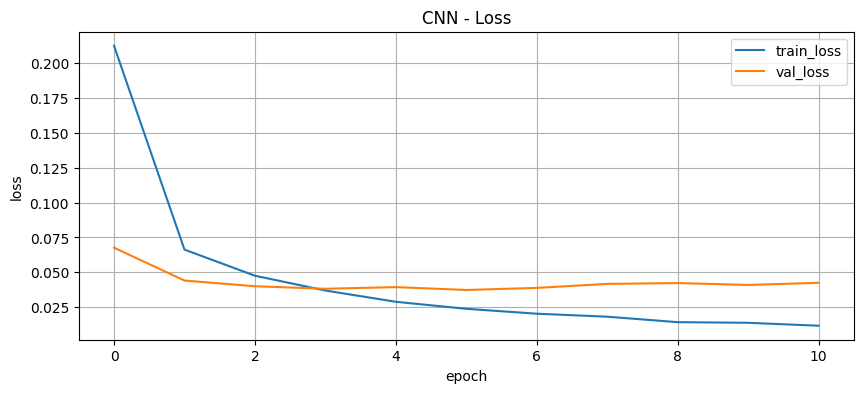

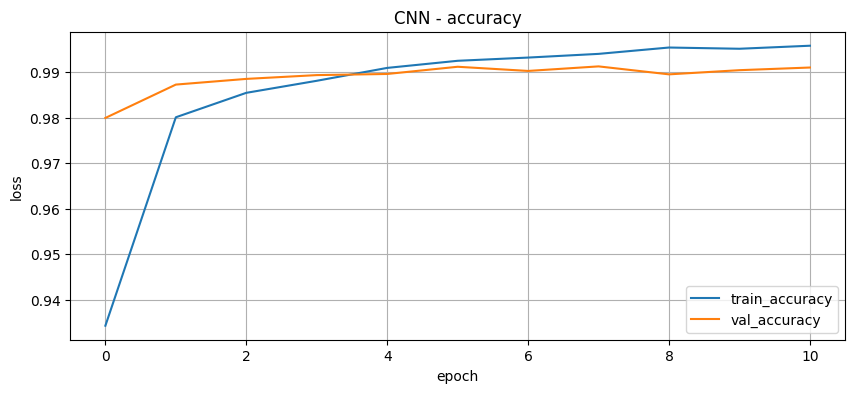

In [53]:
# ================================
# 10. 결과 시각화
# ================================

# 학습 손실 그패프
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('CNN - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)    # 그래프를 격자로 표시
plt.show()                      

plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('CNN - accuracy')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)    # 그래프를 격자로 표시
plt.show()

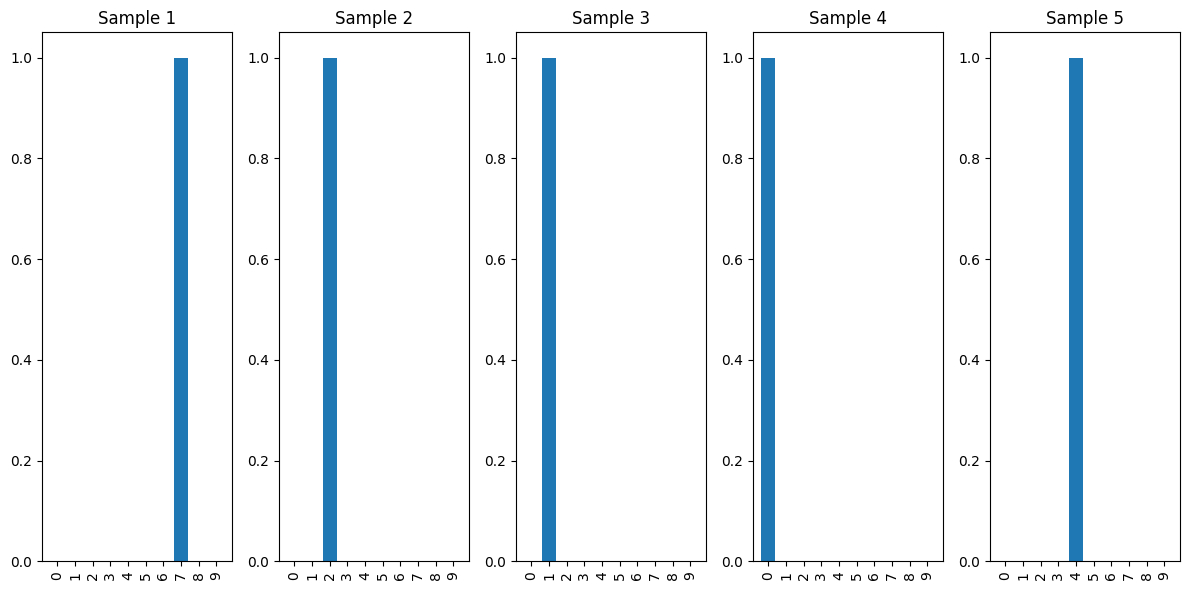

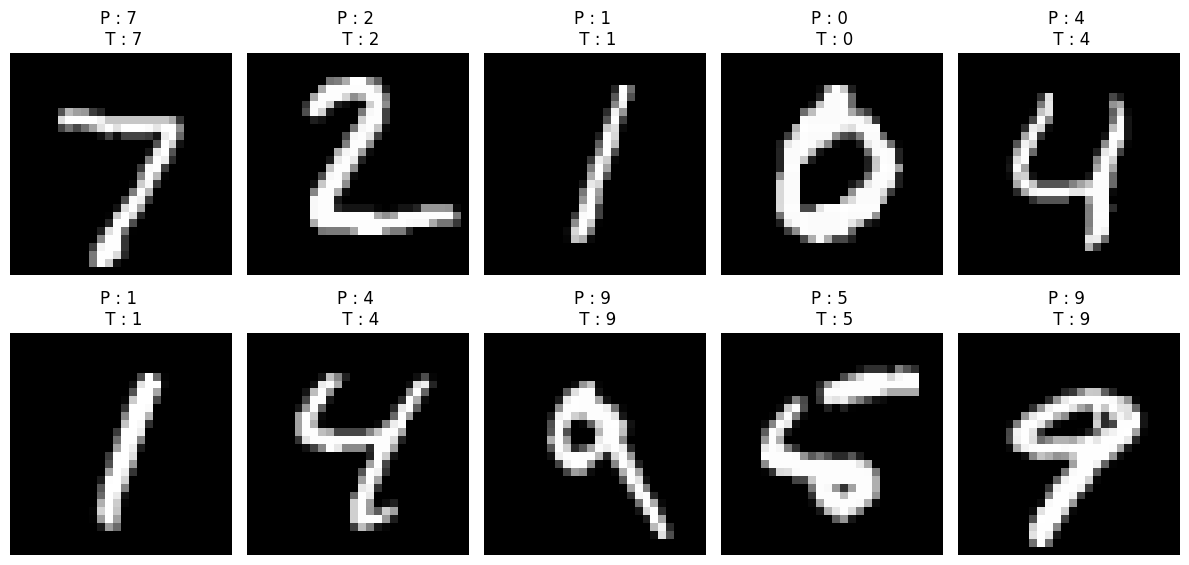

In [55]:
# 테스트 이미지와 예측 결과 시각화
plt.figure(figsize=(12,6))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.bar(range(10), new_prob[i])
    plt.title(f"Sample {i+1}")
    plt.xticks(range(10), rotation=90)

plt.tight_layout()
plt.show()

# 신규 이미지 5개에 대하 확률 분포 시각화
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"P : {class_names[y_pred[i]]} \n T : {class_names[y_test[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()